# 2026-003 shRunt Redo

This notebook details analysis of shRunt experiment for Extended Fig 05

## Initalization

Load packages needed for analysis.

**Note!** This notebook uses a frozen version of **fcexpr** (*dsalbao/fcexpr*) that was forked from *close-your-eyes*'s GitHub repository (*close-your-eyes/fcexpr*). The updated version does not support the commands used in this notebook.

In [1]:
# Load R Packages
library(fcexpr) # Reads FlowJo Workspace files
library(ggplot2)
library(cowplot)
library(ggpubr)
library(ggsci)
library(ggprism)
library(tidyr)
library(dplyr)


Attaching package: ‘ggpubr’


The following object is masked from ‘package:cowplot’:

    get_legend



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Load  FlowJo Workspace

In [2]:
# Set Working Directory
setwd("/home/dalbao/AlbaoRunx3Manuscript/flow/Fig03")

# Load flow processing functions
source("/home/dalbao/AlbaoRunx3Manuscript/flow/scripts/flowProcessing.R")

# Load Workspace (or cached version if it exists)
day8 <- load_workspace_cached(
                wsp_file = "D8P3-260206-SingletAware.wsp",
                rds_file = "D8P3.rds",
                overwrite = FALSE # Set to TRUE to reprocess WSP and overwrite cached workspace
        )
day6 <- load_workspace_cached(
                wsp_file = "D6P3-260204-Reduced.wsp",
                rds_file = "D6P3.rds",
                overwrite = FALSE # Set to TRUE to reprocess WSP and overwrite cached workspace
        )



# Extract Counts
counts.d8 <- day8[["counts"]]
counts.d6 <- day6[["counts"]]


# Preview
head(counts.d6)
head(counts.d8)


Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘purrr’


The following objects are masked from ‘package:rlang’:

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice




,FileName,PopulationFullPath,Parent,Population,Count,ParentCount,FractionOfParent,xDim,yDim,eventsInside,FilePath,FlowJoGroup,ws
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,01-shCd19.fcs,root,NA,root,454253,NA,NA,NA,NA,NA,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D6P3/01-shCd19.fcs,Concat,D6P3-260204-Reduced.wsp
2,01-shCd19.fcs,Lymphocytes,root,Lymphocytes,453884,454253,0.9991877,FSC-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D6P3/01-shCd19.fcs,Concat,D6P3-260204-Reduced.wsp
3,01-shCd19.fcs,Lymphocytes/Single Cells,Lymphocytes,Lymphocytes/Single Cells,451962,453884,0.9957654,FSC-H,FSC-W,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D6P3/01-shCd19.fcs,Concat,D6P3-260204-Reduced.wsp
4,01-shCd19.fcs,Lymphocytes/Single Cells/Single Cells,Lymphocytes/Single Cells,Single Cells/Single Cells,451590,451962,0.9991769,SSC-H,SSC-W,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D6P3/01-shCd19.fcs,Concat,D6P3-260204-Reduced.wsp
5,01-shCd19.fcs,Lymphocytes/Single Cells/Single Cells/Live,Lymphocytes/Single Cells/Single Cells,Live,451590,451590,1.0000000,Comp-Alexa Fluor 700-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D6P3/01-shCd19.fcs,Concat,D6P3-260204-Reduced.wsp
6,01-shCd19.fcs,Lymphocytes/Single Cells/Single Cells/Live/CD8,Lymphocytes/Single Cells/Single Cells/Live,CD8,451590,451590,1.0000000,Comp-BUV496-A,Comp-BUV 396-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D6P3/01-shCd19.fcs,Concat,D6P3-260204-Reduced.wsp


,FileName,PopulationFullPath,Parent,Population,Count,ParentCount,FractionOfParent,xDim,yDim,eventsInside,FilePath,FlowJoGroup,ws
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,CD8.fcs,root,NA,root,4881200,NA,NA,NA,NA,NA,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D8P3%20redo/CD8.fcs,Test,D8P3-260206-SingletAware.wsp
2,CD8.fcs,Lymphocytes,root,Lymphocytes,4777234,4881200,0.9787007,FSC-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D8P3%20redo/CD8.fcs,Test,D8P3-260206-SingletAware.wsp
3,CD8.fcs,Lymphocytes/Single Cells,Lymphocytes,Lymphocytes/Single Cells,3841552,4777234,0.8041373,FSC-W,FSC-H,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D8P3%20redo/CD8.fcs,Test,D8P3-260206-SingletAware.wsp
4,CD8.fcs,Lymphocytes/Single Cells/Single Cells,Lymphocytes/Single Cells,Single Cells/Single Cells,3597465,3841552,0.9364614,SSC-W,SSC-H,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D8P3%20redo/CD8.fcs,Test,D8P3-260206-SingletAware.wsp
5,CD8.fcs,Lymphocytes/Single Cells/Single Cells/Live,Lymphocytes/Single Cells/Single Cells,Live,3597353,3597465,0.9999689,Comp-Alexa Fluor 700-A,SSC-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D8P3%20redo/CD8.fcs,Test,D8P3-260206-SingletAware.wsp
6,CD8.fcs,Lymphocytes/Single Cells/Single Cells/Live/CD8,Lymphocytes/Single Cells/Single Cells/Live,CD8,3597318,3597353,0.9999903,Comp-BB790-A,Comp-BUV 396-A,1,/D:/UF%20Dropbox/SCRPS-PipkinLab/Dominic%20Albao/Experiments/2026-003%20shRunt%20Redo/2026-003%20shRunt%20Redo%20D8P3%20redo/CD8.fcs,Test,D8P3-260206-SingletAware.wsp


In [3]:
# Load Key Files
key.d6 <- read.csv("D6P3_Key.csv")
key.d8 <- read.csv("D8P3_Key.csv")

## Process Surface Staining data

In [4]:
# Define a function that takes counts, key and day label and returns a data frame with the processed data
process_counts <- function(counts, key, day_label) {
    # Filter only samples in "Reduced" FlowJoGroup
    surface <- counts %>% filter((FlowJoGroup %in% c("Reduced")))

    # FileName is of the form export_[\d{6}]_CD8.fcs
    # Only keep the number which is the unique sample identifier
    surface <- surface %>%
        mutate(
            FileName = str_remove(FileName, "^export_"),
            FileName = str_remove(FileName, "_CD8\\.fcs$")
        )

    # key contains a mapping of FileName to MouseID, and Group
    # First, process key$NumericFilename by removing .fcs at the end
    key <- key %>%
        mutate(
            NumericFilename = str_remove(NumericFilename, "\\.fcs$")
        )
    # Join surface with key to get MouseID and Group
    surface <- surface %>%
        left_join(  key[c("NumericFilename", "MouseID", "Group")],
                    by = c("FileName" = "NumericFilename"))

    # Multiply FractionOfParent by 100 and rename to Percent
    surface <- surface %>%
        mutate(FractionOfParent = FractionOfParent * 100) %>%
        rename(Percent = FractionOfParent)

    # Add a column for Day
    surface <- surface %>%
        mutate(Day = day_label)
    
    # Keep only observations in surface wherin PopulationFullPath is in
    # "Lymphocytes/Single Cells/Single Cells/Live/"
    surface <- surface %>%
        filter(grepl("Lymphocytes/Single Cells/Single Cells/Live/", PopulationFullPath))

    # Remove "Lymphocytes/Single Cells/Single Cells/Live/" from PopulationFullPath
    surface <- surface %>%
        mutate(PopulationFullPath = gsub("Lymphocytes/Single Cells/Single Cells/Live/", "", PopulationFullPath))
    # Select relevant columns
    surface <- surface %>%
        # Rename Mouse ID to ID
        mutate(ID = MouseID) %>%
        select(-MouseID) %>%
        select(FileName, ID, Group, Day, PopulationFullPath, Count, Percent)

}

surface.d6 <- process_counts(counts.d6, key.d6, 6)
surface.d8 <- process_counts(counts.d8, key.d8, 8)

In [5]:
# Day 8 data is collected from 2 separate FCS files to expand event capture
# Combine the two FCS files by weighted average of Percent, weighted by Count
surface.d8_weighted <- surface.d8 %>%
    group_by(ID, Group, Day, PopulationFullPath) %>%
    summarise(
        Percent = weighted.mean(Percent, w = Count, na.rm = TRUE),
        Count   = sum(Count, na.rm = TRUE),
        .groups = "drop"
    )

head(surface.d8_weighted)

ID,Group,Day,PopulationFullPath,Percent,Count
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
8A1,shCd19,8,CD8,100.000000,530454
8A1,shCd19,8,CD8/Endogenous,81.024082,429795
8A1,shCd19,8,CD8/Transferred,18.937047,100450
8A1,shCd19,8,CD8/Transferred/Transduced,69.767102,70081
8A1,shCd19,8,CD8/Transferred/Transduced/Fate-DP,2.301849,1613
8A1,shCd19,8,CD8/Transferred/Transduced/Fate-DP/Gerlach-Tcm,24.385885,392


In [6]:
# Before combining the two days, harmonize gating strategies in PpopulationFullPath

# Drop FileName and keep only with "Transduced/" in PopulationFullPath and remove gates Trnasduced/ and above
surface.d6 <- surface.d6 %>% 
    select(-FileName) %>%
    filter(grepl("Transduced/", PopulationFullPath)) %>%
    mutate(PopulationFullPath = gsub(".*Transduced/", "", PopulationFullPath))

surface.d8_weighted <- surface.d8_weighted %>% 
    filter(grepl("Transduced/", PopulationFullPath)) %>%
    mutate(PopulationFullPath = gsub(".*Transduced/", "", PopulationFullPath))

# Combine the two days
surface <- bind_rows(surface.d6, surface.d8_weighted)
surface$Day <- factor(surface$Day, levels = c(6, 8))
surface$Group <- factor(surface$Group, levels = c("shCd19", "shRunx1", "shRunx2", "shRunx3", "shCbfb"))

# Without rounding at all
total_percent <- compute_percent_of_total(surface) %>%
    add_population_derivatives() %>%
    finalize_flow_table(round_digits = NULL)

head(total_percent, n = 20)

#   Export to CSV
write.csv(total_percent, "2026-003-shRuntRedo.csv", row.names = FALSE, quote = FALSE)

ID,Group,Population,Population1Deriv,Day,Count,Percent,PercentOfTotal
<chr>,<fct>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>
6A1,shCd19,Fate-DP,NA,6,117,0.4639911,0.463991117
6A1,shCd19,Fate-DP,Gerlach-Tcm,6,79,67.5213675,0.313293147
6A1,shCd19,Fate-DP,Gerlach-Tem,6,3,2.5641026,0.011897208
6A1,shCd19,Fate-DP,Gerlach-Tpm,6,17,14.5299145,0.067417513
6A1,shCd19,Fate-DP,Kaech-DP,6,3,2.5641026,0.011897208
6A1,shCd19,Fate-DP,Kaech-EE,6,73,62.3931624,0.289498731
6A1,shCd19,Fate-DP,Kaech-MP,6,30,25.6410256,0.118972081
6A1,shCd19,Fate-DP,Kaech-TE,6,11,9.4017094,0.043623096
6A1,shCd19,Fate-DP,Pipkin-Exh,6,14,11.9658120,0.055520305


## Plot

In [7]:
# Create a default theme
colors <- c(
    "shCd19"    = "#808180",
    "shRunx1"   = "#96A648",
    "shRunx2"   = "#FAC85C",
    "shRunx3"   = "#DC0000",
    "shCbfb"    = "#557D6E"
)

# Use ggprism, base 12, not bold, and remove legend
theme <- theme_bw(      base_size = 14,
                        base_family = "sans",
                        #base_fontface = "plain"
                        ) +
    theme(  axis.text = element_text(size = 10),
            axis.title = element_text(size = 12),
            axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 12),
            axis.title.x = element_blank(),            strip.text = element_text(size = 12),
            legend.position = "none",
            plot.title = element_text(size = 12),  # Set main title size
            panel.grid = element_blank())  # Remove gridlines

In [8]:
subset <- total_percent %>%
    filter(grepl("Gerlach-|Pipkin-|Kaech-|Fate-", Population), is.na(Population1Deriv))

head(subset)

ID,Group,Population,Population1Deriv,Day,Count,Percent,PercentOfTotal
<chr>,<fct>,<chr>,<chr>,<fct>,<dbl>,<dbl>,<dbl>
6A1,shCd19,Fate-DP,NA,6,117,0.4639911,0.4639911
6A1,shCd19,Fate-TE,NA,6,8490,33.6690990,33.6690990
6A1,shCd19,Fate-TcmE,NA,6,601,2.3834074,2.3834074
6A1,shCd19,Fate-TcmL,NA,6,16008,63.4835025,63.4835025
6A1,shCd19,Gerlach-Tcm,NA,6,4390,17.4095812,17.4095812
6A1,shCd19,Gerlach-Tem,NA,6,10190,40.4108503,40.4108503


In [9]:
# Define plot groups
plot_groups <- list(
    Gerlach = c("Tcm", "Tpm", "Tem"),
    Kaech = c("EE", "MP", "DP", "TE"),
    Pipkin = c("TcmE", "TcmL", "TE", "Exh"),
    Fate = c("TcmE", "DP", "TcmL", "TE")
)

comparisons <- list(
    c("shCd19", "shRunx1"),
    c("shCd19", "shRunx2"),
    c("shCd19", "shRunx3"),
    c("shCd19", "shCbfb")
)

plot_facet_groups <- function(pGroup, df, ncol = 2) {

    plot.data.df <- subset %>%
        filter(grepl(pGroup, Population)) %>%
        filter(Population %in% paste0(pGroup, "-", plot_groups[[pGroup]])) %>%
        mutate(Population = gsub(pattern = paste0(pGroup, "-"), replacement = "" , x = Population)) %>%
        mutate(Population = factor(Population, levels = plot_groups[[pGroup]])) %>%
        mutate(facet = interaction(Day, Population, lex.order = TRUE)) %>%
        arrange(facet, ID)

    # Calculate p-values and BH-adjusted p-values for mock vs. Runx3
    plot.stat.df <- plot_padj(
        data = plot.data.df,
        comparisons = comparisons,
        y_col = "Percent",
        x_col = "Group",
        facet_col = "facet",
        step_fraction = 0.1,
        min_step = 0.5
    )

    # Save comparison statistics (p, p.adj, fold changes) to CSV
    write.csv(plot.stat.df, paste0("2024-003-EFig05_", pGroup, ".csv"))

    # Round plot.stat.df column foldmean to one significant digit
    # Then concatenate to p.adj.signif only if not "ns", into column p.adj.fold
    plot.stat.df <- plot.stat.df %>%
        mutate(foldmeanround = signif(foldmean, digits = 2)) %>%
        mutate(p.adj.fold = ifelse(p.adj.signif == "ns", "ns", paste0(p.adj.signif, " (", foldmeanround, "x)")))

    # Only the significant comparisons get a bracket drawn (see
    # stat_pvalue_manual below), so only these need extra headroom
    plot.stat.sig <- plot.stat.df %>% filter(p.adj < 0.05)

    # Create the plot
    p <- ggplot(plot.data.df, aes(x = Group, y = Percent, fill = Group)) +
        geom_boxplot(outlier.shape = NA) +
        geom_point(size = 1) +
        facet_wrap(~ facet, ncol = ncol, scales = "free_y") +
        theme +
        scale_fill_manual(values = colors) +
        # Make room for the p-value bracket: with scales = "free_y", each panel
        # auto-scales to plot.data.df alone, so the bracket drawn at y.position
        # (above the tallest box, per plot_padj()'s step_fraction/min_step) would
        # get clipped at the top of the panel without this. geom_blank() is
        # invisible but still trains the y-scale, and a small multiplier adds
        # headroom for the label text sitting above the bracket line itself.
        geom_blank( data = plot.stat.sig, aes(x = group1, y = y.position),
                    inherit.aes = FALSE) +
        scale_y_continuous(expand = expansion(mult = c(0.05, 0.10))) +
        stat_pvalue_manual(
            plot.stat.sig,
            label = "p.adj.signif",   # adjusted p-value stars
            tip.length = 0.01,
            size = 4,
            inherit.aes = FALSE       # important fix
        )
}

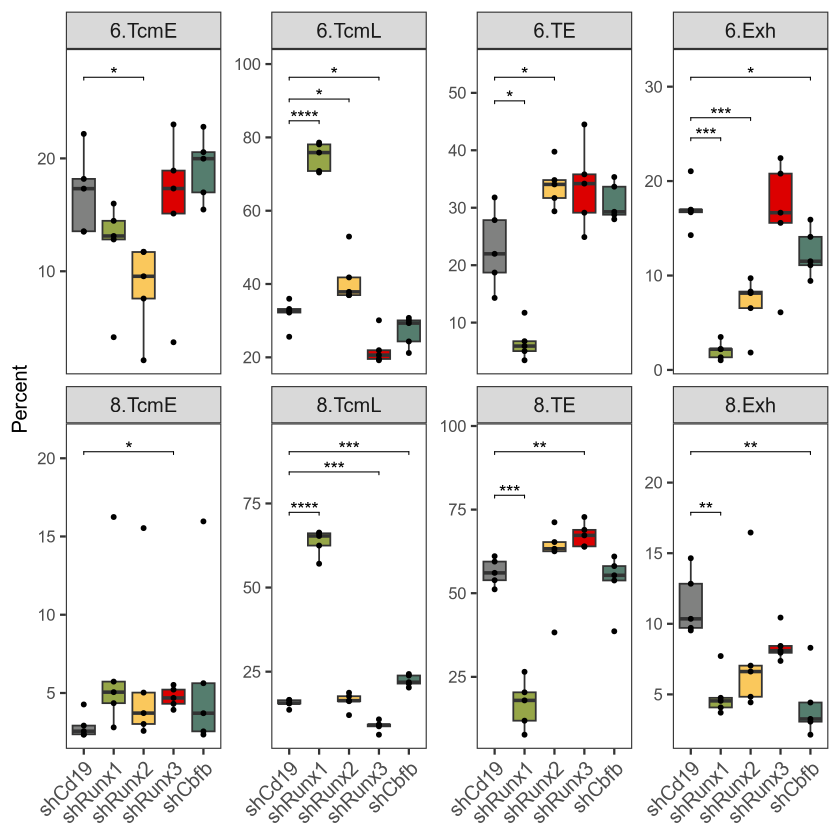

In [10]:
p <- plot_facet_groups("Pipkin", subset, ncol = 4)
print(p)

In [11]:
pdf(file =  paste0("2026-003-EFig05_", "Pipkin", ".pdf"), width = 5, height = 3)

p   <- p + 
    theme(  axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 1),
            strip.text = element_blank(),
            strip.background = element_blank()) +
    scale_x_discrete(labels = c(
        "shCd19"    = "a",
        "shRunx1"   = "b",
        "shRunx2"   = "c",
        "shRunx3"   = "d",
        "shCbfb"    = "e"
    ))

print(p)

dev.off()

pdf 
  2

pdf 
  2

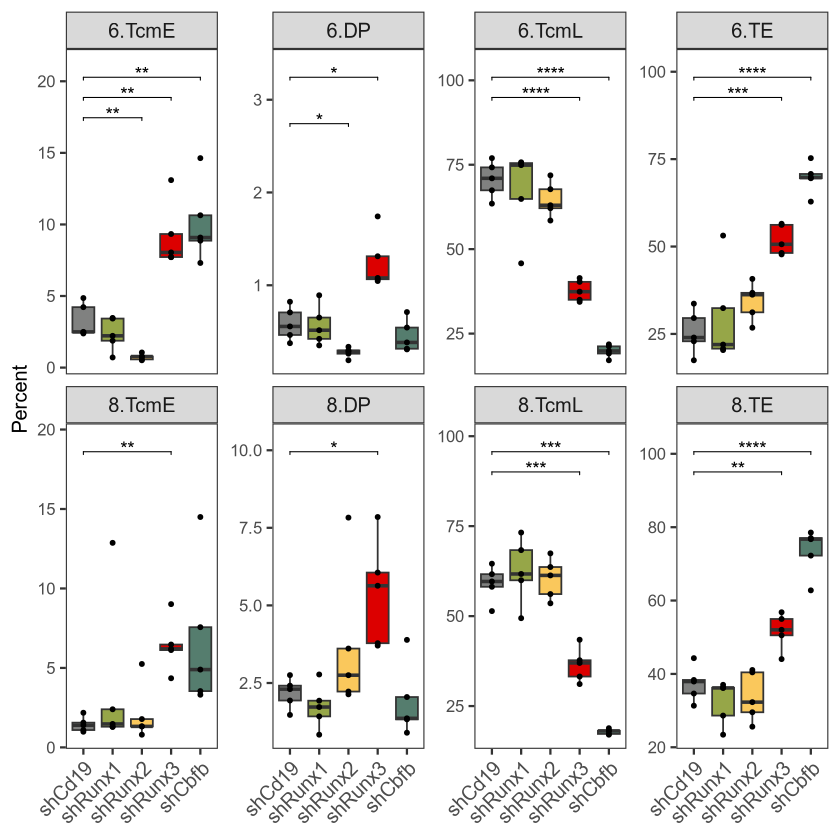

In [12]:
p <- plot_facet_groups("Fate", subset, ncol = 4)
print(p)

pdf(file =  paste0("2026-003-EFig05_", "Fate", ".pdf"), width = 5, height = 3)

p   <- p + 
    theme(  axis.text.x = element_text(angle = 0, hjust = 0.5, vjust = 1),
            strip.text = element_blank(),
            strip.background = element_blank()) +
    scale_x_discrete(labels = c(
        "shCd19"    = "a",
        "shRunx1"   = "b",
        "shRunx2"   = "c",
        "shRunx3"   = "d",
        "shCbfb"    = "e"
    ))

print(p)

dev.off()